In [2]:
#Load the weekly dataset
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("../artifacts/weekly.parquet")

df.head()

,item,date,demand
0,1,2013-01-13,863
1,1,2013-01-20,865
2,1,2013-01-27,799
3,1,2013-02-03,954
4,1,2013-02-10,935


In [4]:
#check structure od dataset
# Show the number of rows and columns in the dataset.
print("Shape:", df.shape)

# Show the data type of each column.
print("\nData types:")
print(df.dtypes)

# Count how many unique products we have.
print("\nNumber of products:", df["item"].nunique())

# Show the start and end dates in the dataset.
print("\nDate range:")
print(df["date"].min(), "to", df["date"].max())

Shape: (5200, 3)

Data types:
item               int64
date      datetime64[us]
demand             int64
dtype: object

Number of products: 20

Date range:
2013-01-13 00:00:00 to 2017-12-31 00:00:00


In [5]:
#check missing values 
# Count missing values in every column.
missing = df.isna().sum()

# Display the missing-value count.
print(missing)

item      0
date      0
demand    0
dtype: int64


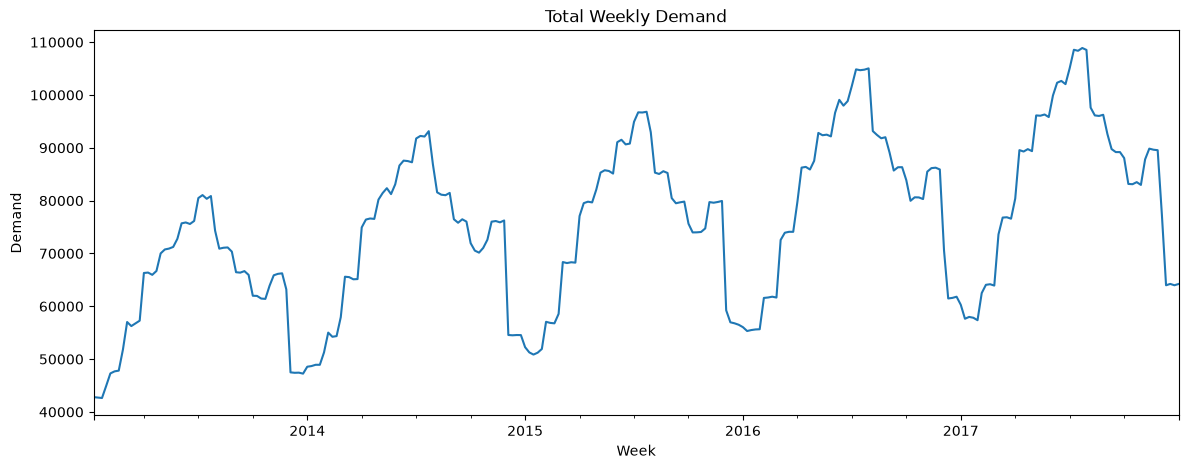

In [6]:
#total demand over time
# Add demand across all 20 products for each week.
total_weekly_demand = df.groupby("date")["demand"].sum()

# Plot total demand over time to look for trends and seasonality.
total_weekly_demand.plot(figsize=(14, 5))

# Add a title and axis labels to make the chart readable.
plt.title("Total Weekly Demand")
plt.xlabel("Week")
plt.ylabel("Demand")

# Display the chart.
plt.show()

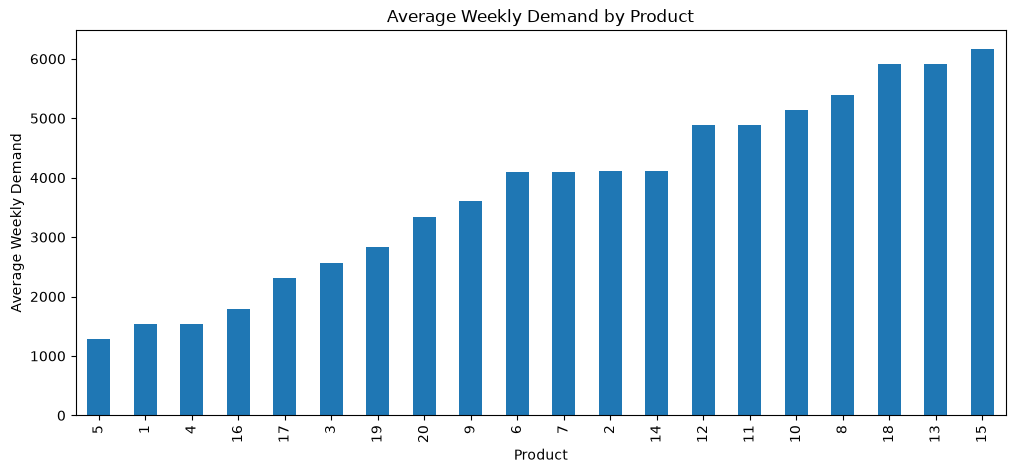

In [7]:
#Compare average demand across products
# Calculate the average weekly demand for each product.
average_demand = df.groupby("item")["demand"].mean().sort_values()

# Create a bar chart comparing products.
average_demand.plot(kind="bar", figsize=(12, 5))

# Add labels to explain the chart.
plt.title("Average Weekly Demand by Product")
plt.xlabel("Product")
plt.ylabel("Average Weekly Demand")

# Display the chart.
plt.show()

In [8]:
#Basic demand statistics
# Calculate basic statistics such as mean, standard deviation,
# minimum, maximum, and quartiles for weekly demand.
df["demand"].describe()

count    5200.000000
mean     3775.770000
std      1750.572839
min       692.000000
25%      2282.750000
50%      3677.000000
75%      5015.000000
max      9090.000000
Name: demand, dtype: float64

In [9]:
# Count the number of weekly observations available for each product.
weeks_per_item = df.groupby("item")["date"].nunique()

# Display the number of weeks for every product.
print(weeks_per_item)

item
1     260
2     260
3     260
4     260
5     260
6     260
7     260
8     260
9     260
10    260
11    260
12    260
13    260
14    260
15    260
16    260
17    260
18    260
19    260
20    260
Name: date, dtype: int64
